## 0. Librerías

In [2]:
import pandas as pd
import numpy as np
import re
import json
import ast
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR   = Path('datasets/')
OUTPUT_DIR = Path('outputs/')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Librerías OK')

Librerías OK


## 1. Carga de datasets

In [3]:
# --- US Election 2020 (dataset principal) ---
trump_df = pd.read_csv(
    DATA_DIR / 'hashtag_donaldtrump.csv',
    on_bad_lines='skip',
    engine='python'
)
biden_df = pd.read_csv(
    DATA_DIR / 'hashtag_joebiden.csv',
    on_bad_lines='skip',
    engine='python'
)

trump_df['candidate'] = 'trump'
biden_df['candidate'] = 'biden'

election_df = pd.concat([trump_df, biden_df], ignore_index=True)
print(f'US Election 2020 total: {len(election_df):,} tweets')
print('candidate en election_df:', 'candidate' in election_df.columns)

US Election 2020 total: 1,748,160 tweets
candidate en election_df: True


In [4]:
# --- Datasets secundarios (cargados, pendientes de integrar) ---
twitter_df  = pd.read_csv(DATA_DIR / 'twitter_dataset.csv', on_bad_lines='skip', engine='python')
bot_df      = pd.read_csv(DATA_DIR / 'bot_detection_data.csv', on_bad_lines='skip', engine='python')

with open(DATA_DIR / 'cleaned_twitter_elections_data.json', 'r', encoding='utf-8') as f:
    pakistan_raw = json.load(f)
pakistan_df = pd.DataFrame(pakistan_raw) if isinstance(pakistan_raw, list) else pd.json_normalize(pakistan_raw)

print(f'Twitter general:  {len(twitter_df):,} registros')
print(f'Bot detection:    {len(bot_df):,} registros')
print(f'Pakistan 2018:    {len(pakistan_df):,} registros')

Twitter general:  10,000 registros
Bot detection:    50,000 registros
Pakistan 2018:    29,579 registros


## 2. Limpieza de datos
### 2.1 Selección y renombrado de columnas

In [5]:
COLS_ELECTION = {
    'tweet_id':            'tweet_id',
    'tweet':               'text',
    'created_at':          'created_at',
    'user_id':             'user_id',
    'user_screen_name':    'user_screen_name',
    'user_followers_count':'followers_count',
    'user_join_date':      'user_join_date',
    'likes':               'likes',
    'retweet_count':       'retweet_count',
    'source':              'source',
    'user_location':       'user_location',
    'state':               'state',
    'country':             'country',
    'candidate':           'candidate'
}

df = election_df[[c for c in COLS_ELECTION if c in election_df.columns]].rename(columns=COLS_ELECTION)
print(f'Columnas: {df.columns.tolist()}')
print(f'candidate en df: {"candidate" in df.columns}')

Columnas: ['tweet_id', 'text', 'created_at', 'user_id', 'user_screen_name', 'followers_count', 'user_join_date', 'likes', 'retweet_count', 'source', 'user_location', 'state', 'country', 'candidate']
candidate en df: True


In [6]:
df.head()

,tweet_id,text,created_at,user_id,user_screen_name,followers_count,user_join_date,likes,retweet_count,source,user_location,state,country,candidate
0,1.316529221557252e+18,#Elecciones2020 | En #Florida: #JoeBiden dice ...,2020-10-15 00:00:01,360666534.0,elsollatinonews,1860.0,2011-08-23 15:33:45,0.0,0.0,TweetDeck,"Philadelphia, PA / Miami, FL",Florida,United States of America,trump
1,1.3165292227484303e+18,"Usa 2020, Trump contro Facebook e Twitter: cop...",2020-10-15 00:00:01,331617619.0,MediasetTgcom24,1067661.0,2011-07-08 13:12:20,26.0,9.0,Social Mediaset,NaN,NaN,NaN,trump
2,1.316529228091847e+18,"#Trump: As a student I used to hear for years,...",2020-10-15 00:00:02,8436472.0,snarke,1185.0,2007-08-26 05:56:11,2.0,1.0,Twitter Web App,Portland,Oregon,United States of America,trump
3,1.316529227471237e+18,2 hours since last tweet from #Trump! Maybe he...,2020-10-15 00:00:02,8.28355589206057e+17,trumpytweeter,32.0,2017-02-05 21:32:17,0.0,0.0,Trumpytweeter,NaN,NaN,NaN,trump
4,1.3165292523014513e+18,You get a tie! And you get a tie! #Trump ‘s ra...,2020-10-15 00:00:08,47413798.0,Ranaabtar,5393.0,2009-06-15 19:05:35,4.0,3.0,Twitter for iPhone,Washington DC,District of Columbia,United States of America,trump


### 2.2 Duplicados

In [7]:
n_before = len(df)
df = df.drop_duplicates(subset='tweet_id')
print(f'Duplicados eliminados: {n_before - len(df):,} | Registros restantes: {len(df):,}')

Duplicados eliminados: 225,215 | Registros restantes: 1,522,945


### 2.3 Valores faltantes

In [8]:
# Mostrar nulos antes de limpiar
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0')

,missing,pct
tweet_id,1,0.00
text,1,0.00
user_id,38,0.00
user_screen_name,34,0.00
followers_count,250,0.02
user_join_date,280,0.02
likes,20,0.00
retweet_count,34,0.00
source,1009,0.07
user_location,462967,30.40


In [9]:
# Eliminar filas sin texto ni timestamp
df = df.dropna(subset=['text', 'created_at'])

# Forzar tipos numéricos antes de rellenar
df['likes']           = pd.to_numeric(df['likes'],           errors='coerce').fillna(0)
df['retweet_count']   = pd.to_numeric(df['retweet_count'],   errors='coerce').fillna(0)
df['followers_count'] = pd.to_numeric(df['followers_count'], errors='coerce').fillna(0)

# Rellenar opcionales
df['user_location'] = df['user_location'].fillna('unknown')
df['state']         = df['state'].fillna('unknown')
df['country']       = df['country'].fillna('unknown')
df['source']        = df['source'].fillna('unknown')

print(f'Registros finales: {len(df):,}')

Registros finales: 1,522,944


## 3. Normalización temporal

In [10]:
#df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
#df = df.dropna(subset=['created_at'])

#df['date']        = df['created_at'].dt.date
#df['hour']        = df['created_at'].dt.hour
#df['day_of_week'] = df['created_at'].dt.dayofweek
#df['week']        = df['created_at'].dt.isocalendar().week.astype(int)
#df['hour_window'] = df['created_at'].dt.floor('1h')

#print(f'Rango temporal: {df["created_at"].min().date()} → {df["created_at"].max().date()}')

In [11]:
df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce', origin='unix')
df.head()

,tweet_id,text,created_at,user_id,user_screen_name,followers_count,user_join_date,likes,retweet_count,source,user_location,state,country,candidate
0,1.316529221557252e+18,#Elecciones2020 | En #Florida: #JoeBiden dice ...,2020-10-15 00:00:01+00:00,360666534.0,elsollatinonews,1860.0,2011-08-23 15:33:45,0.0,0.0,TweetDeck,"Philadelphia, PA / Miami, FL",Florida,United States of America,trump
1,1.3165292227484303e+18,"Usa 2020, Trump contro Facebook e Twitter: cop...",2020-10-15 00:00:01+00:00,331617619.0,MediasetTgcom24,1067661.0,2011-07-08 13:12:20,26.0,9.0,Social Mediaset,unknown,unknown,unknown,trump
2,1.316529228091847e+18,"#Trump: As a student I used to hear for years,...",2020-10-15 00:00:02+00:00,8436472.0,snarke,1185.0,2007-08-26 05:56:11,2.0,1.0,Twitter Web App,Portland,Oregon,United States of America,trump
3,1.316529227471237e+18,2 hours since last tweet from #Trump! Maybe he...,2020-10-15 00:00:02+00:00,8.28355589206057e+17,trumpytweeter,32.0,2017-02-05 21:32:17,0.0,0.0,Trumpytweeter,unknown,unknown,unknown,trump
4,1.3165292523014513e+18,You get a tie! And you get a tie! #Trump ‘s ra...,2020-10-15 00:00:08+00:00,47413798.0,Ranaabtar,5393.0,2009-06-15 19:05:35,4.0,3.0,Twitter for iPhone,Washington DC,District of Columbia,United States of America,trump


In [12]:
if 'user_join_date' in df.columns:
    df['user_join_date']    = pd.to_datetime(df['user_join_date'], utc=True, errors='coerce')
    df['account_age_days']  = (df['created_at'] - df['user_join_date']).dt.days.clip(lower=0)
else:
    df['account_age_days'] = np.nan

print('account_age_days OK')

account_age_days OK


## 4. Preprocesamiento textual

In [13]:
tokenizer  = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=False)
lemmatizer = WordNetLemmatizer()
STOP_EN    = set(stopwords.words('english'))

def extract_hashtags(text):
    return re.findall(r'#(\w+)', str(text).lower())

def extract_mentions(text):
    return re.findall(r'@(\w+)', str(text).lower())

def is_retweet(text):
    return str(text).strip().startswith('RT @')

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'RT\s@\w+:', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s#]', '', text)
    tokens = tokenizer.tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in STOP_EN and len(t) > 2 and not t.startswith('#')
    ]
    return ' '.join(tokens)

print('Funciones de texto definidas')

Funciones de texto definidas


In [14]:
df['hashtags']  = df['text'].apply(extract_hashtags)
df['mentions']  = df['text'].apply(extract_mentions)
df['is_retweet']= df['text'].apply(is_retweet).astype(int)
df['n_hashtags']= df['hashtags'].apply(len)
df['n_mentions']= df['mentions'].apply(len)

print('Limpiando texto (puede tardar unos minutos)...')
df['text_clean'] = df['text'].apply(clean_text)
print('Texto limpiado')

Limpiando texto (puede tardar unos minutos)...
Texto limpiado


## 5. Feature Engineering
### 5.1 Actividad por cuenta

In [18]:
df['likes']         = pd.to_numeric(df['likes'],         errors='coerce').fillna(0)
df['retweet_count'] = pd.to_numeric(df['retweet_count'], errors='coerce').fillna(0)
df['n_hashtags']    = pd.to_numeric(df['n_hashtags'],    errors='coerce').fillna(0)

user_activity = (
    df.groupby('user_id')
    .agg(
        total_tweets  =('tweet_id',    'count'),
        total_retweets=('is_retweet',  'sum'),
        #unique_days   =('date',        'nunique'),
        avg_likes     =('likes',       'mean'),
        avg_rt        =('retweet_count','mean'),
        avg_hashtags  =('n_hashtags',  'mean'),
    )
    .reset_index()
)
user_activity['retweet_ratio'] = (
    user_activity['total_retweets'] / user_activity['total_tweets'].clip(lower=1)
)

df = df.merge(user_activity, on='user_id', how='left')
print(f'Cuentas únicas: {len(user_activity):,}')

Cuentas únicas: 483,194


### 5.2 Densidad temporal por ventana de 1 hora

In [21]:
#window_activity = (
#    df.groupby('hour_window')
#    .agg(
#        tweets_in_window      =('tweet_id',   'count'),
#        unique_users_in_window=('user_id',    'nunique'),
#        rt_in_window          =('is_retweet', 'sum'),
#    )
#    .reset_index()
#)
#window_activity['rt_ratio_window'] = (
#    window_activity['rt_in_window'] / window_activity['tweets_in_window'].clip(lower=1)
#)

#df = df.merge(window_activity, on='hour_window', how='left')
#print('Features de ventana temporal creadas')

### 5.3 Muestra estratificada

In [22]:
SAMPLE_N = 200_000

trump_sample = df[df['candidate'] == 'trump'].sample(
    min(len(df[df['candidate'] == 'trump']), SAMPLE_N // 2), random_state=42)
biden_sample = df[df['candidate'] == 'biden'].sample(
    min(len(df[df['candidate'] == 'biden']), SAMPLE_N // 2), random_state=42)

df_sample = pd.concat([trump_sample, biden_sample]).reset_index(drop=True)

print(f'Muestra de trabajo: {len(df_sample):,} tweets')
print(f'candidate en df_sample: {"candidate" in df_sample.columns}')
print(df_sample['candidate'].value_counts())

Muestra de trabajo: 200,000 tweets
candidate en df_sample: True
candidate
trump    100000
biden    100000
Name: count, dtype: int64


### 5.4 Vectorización TF-IDF

In [23]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True
)
tfidf_matrix = tfidf.fit_transform(df_sample['text_clean'])
print(f'Matriz TF-IDF: {tfidf_matrix.shape}')

Matriz TF-IDF: (200000, 5000)


### 5.5 Feature tabular escalada

In [24]:
NUMERIC_FEATURES = [
    'followers_count', 'likes', 'retweet_count',
    'n_hashtags', 'n_mentions', 'is_retweet',
    'hour', 'day_of_week', 'account_age_days',
    'total_tweets', 'retweet_ratio', 'avg_likes',
    'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window',
]

# Usar solo las que existen
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df_sample.columns]
print(f'Features disponibles: {NUMERIC_FEATURES}')

features_df     = df_sample[NUMERIC_FEATURES].fillna(0)
scaler          = MinMaxScaler()
features_scaled = scaler.fit_transform(features_df)
features_scaled_df = pd.DataFrame(features_scaled, columns=NUMERIC_FEATURES)

print(f'Feature matrix: {features_scaled_df.shape}')
features_scaled_df.describe().T[['mean', 'std', 'min', 'max']]

Features disponibles: ['followers_count', 'likes', 'retweet_count', 'n_hashtags', 'n_mentions', 'is_retweet', 'account_age_days']
Feature matrix: (200000, 7)


,mean,std,min,max
followers_count,0.000277,0.004672,0.0,1.0
likes,0.000299,0.005863,0.0,1.0
retweet_count,0.000296,0.006207,0.0,1.0
n_hashtags,0.095533,0.087582,0.0,1.0
n_mentions,0.013650,0.036867,0.0,1.0
is_retweet,0.000150,0.012247,0.0,1.0
account_age_days,0.428288,0.289703,0.0,1.0


## 6. Detección preliminar de anomalías

In [27]:
# p95 = window_activity['tweets_in_window'].quantile(0.95)
# p99 = window_activity['tweets_in_window'].quantile(0.99)
# print(f'Tweets por ventana — P95: {p95:.0f} | P99: {p99:.0f}')

# burst_windows = window_activity[window_activity['tweets_in_window'] >= p95].copy()
# print(f'Ventanas con burst (>= P95): {len(burst_windows):,}')
# burst_windows.sort_values('tweets_in_window', ascending=False).head(10)

## 7. Guardado de artefactos (A3)

In [29]:
# df_sample.to_csv(OUTPUT_DIR / 'df_processed_sample.csv', index=False)
# features_scaled_df.to_csv(OUTPUT_DIR / 'features_scaled.csv', index=False)
# burst_windows.to_csv(OUTPUT_DIR / 'burst_windows.csv', index=False)

# import scipy.sparse as sp
# sp.save_npz(OUTPUT_DIR / 'tfidf_matrix.npz', tfidf_matrix)

# print('Artefactos guardados en outputs/')

## 8. Resumen general del dataset

In [30]:
print('=== Resumen general ===')
print(f"Tweets totales:        {len(df_sample):,}")
print(f"Cuentas únicas:        {df_sample['user_id'].nunique():,}")
print(f"Período:               {df_sample['created_at'].min().date()} → {df_sample['created_at'].max().date()}")
print(f"Retweets:              {df_sample['is_retweet'].sum():,} ({df_sample['is_retweet'].mean()*100:.1f}%)")
print(f"Tweets con hashtag:    {(df_sample['n_hashtags'] > 0).sum():,} ({(df_sample['n_hashtags'] > 0).mean()*100:.1f}%)")
print()
print('--- Por candidato ---')
print(df_sample['candidate'].value_counts())

=== Resumen general ===
Tweets totales:        200,000
Cuentas únicas:        116,267
Período:               2020-10-15 → 2020-11-08
Retweets:              30 (0.0%)
Tweets con hashtag:    199,979 (100.0%)

--- Por candidato ---
candidate
trump    100000
biden    100000
Name: count, dtype: int64


In [31]:
cols_desc = ['likes', 'retweet_count', 'followers_count', 'n_hashtags',
             'n_mentions', 'account_age_days', 'total_tweets', 'retweet_ratio']
cols_desc = [c for c in cols_desc if c in df_sample.columns]
df_sample[cols_desc].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
likes,200000.0,8.40,165.01,0.0,0.0,0.0,2.0,28146.0
retweet_count,200000.0,1.87,39.19,0.0,0.0,0.0,0.0,6313.0
followers_count,200000.0,22804.89,385072.56,0.0,75.0,426.0,2010.0,82417099.0
n_hashtags,200000.0,3.82,3.50,0.0,2.0,3.0,5.0,40.0
n_mentions,200000.0,0.68,1.84,0.0,0.0,0.0,1.0,50.0
account_age_days,199963.0,2236.93,1512.66,0.0,681.0,2420.0,3623.0,5222.0


## 9. Distribución temporal
### 9.1 Tweets por día

### 9.2 Tweets por hora del día

### 9.3 Mapa de calor: actividad hora × día de la semana

In [34]:
# heatmap_data = df_sample.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
# heatmap_data.index = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

# fig, ax = plt.subplots(figsize=(14, 4))
# sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3, cbar_kws={'label': 'Nº tweets'})
# ax.set_title('Actividad por hora y día de la semana', fontsize=14)
# ax.set_xlabel('Hora del día (UTC)')
# ax.set_ylabel('Día de la semana')
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / 'eda_heatmap_hora_dia.png')
# plt.show()

### 9.4 Ventanas con burst de actividad (top 20)

In [37]:
# top20 = burst_windows.head(20)
# fig, ax = plt.subplots(figsize=(14, 5))
# ax.barh(top20['hour_window'].astype(str), top20['tweets_in_window'], color='#E74C3C', alpha=0.85)
# ax.set_title('Top 20 ventanas horarias con mayor actividad (posibles bursts)', fontsize=13)
# ax.set_xlabel('Nº de tweets')
# ax.invert_yaxis()
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / 'eda_burst_windows.png')
# plt.show()

## 10. Análisis de cuentas
### 10.1 Distribución de tweets por cuenta

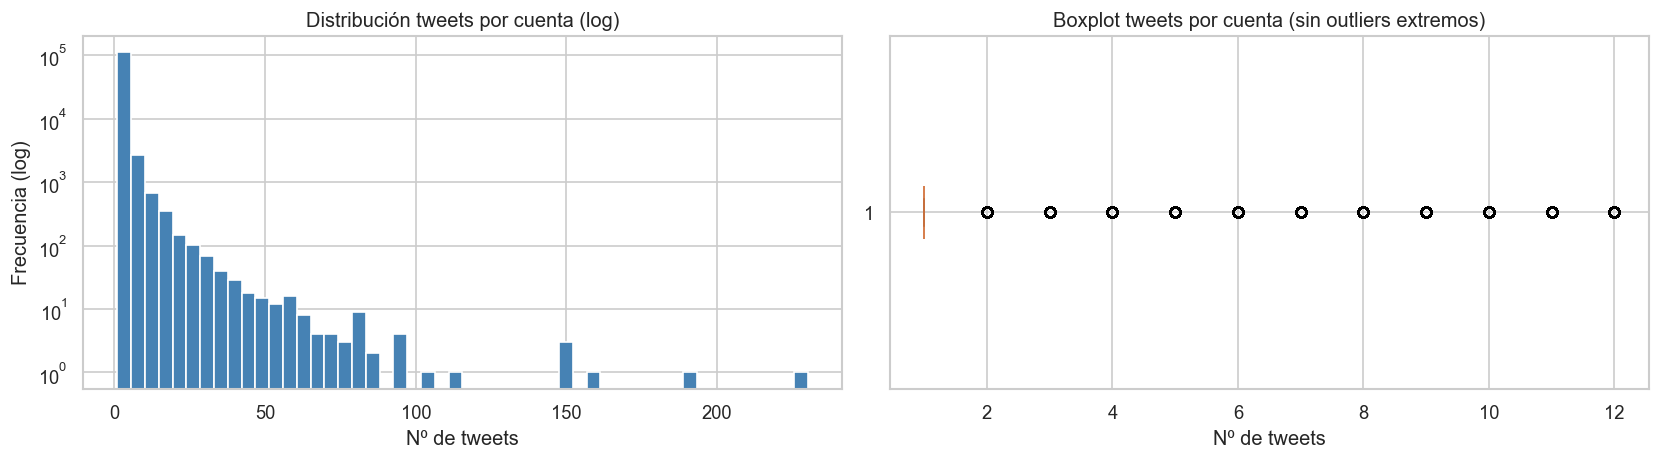

Cuentas con 1 tweet:       89,794
Cuentas con > 50 tweets:   71
Cuentas con > 100 tweets:  8


In [38]:
tweets_per_user = df_sample.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(tweets_per_user, bins=50, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Distribución tweets por cuenta (log)', fontsize=12)
axes[0].set_xlabel('Nº de tweets')
axes[0].set_ylabel('Frecuencia (log)')

axes[1].boxplot(tweets_per_user.clip(upper=tweets_per_user.quantile(0.99)),
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot tweets por cuenta (sin outliers extremos)', fontsize=12)
axes[1].set_xlabel('Nº de tweets')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_tweets_por_cuenta.png')
plt.show()

print(f'Cuentas con 1 tweet:       {(tweets_per_user == 1).sum():,}')
print(f'Cuentas con > 50 tweets:   {(tweets_per_user > 50).sum():,}')
print(f'Cuentas con > 100 tweets:  {(tweets_per_user > 100).sum():,}')

### 10.2 Retweet ratio por cuenta

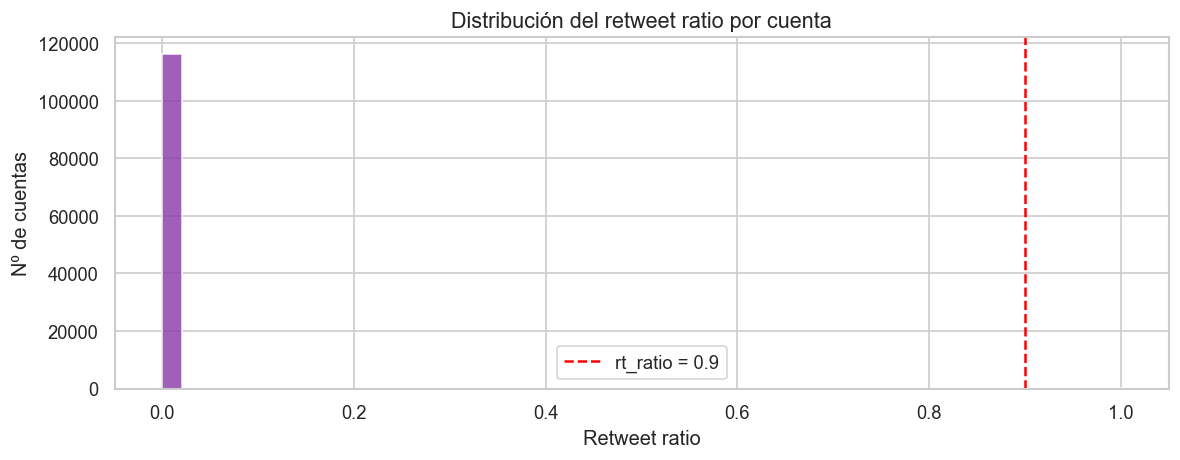

Cuentas con rt_ratio >= 0.9: 15 (0.0%)


In [39]:
user_stats = df_sample.groupby('user_id').agg(
    total=('tweet_id', 'count'),
    rts  =('is_retweet', 'sum')
).reset_index()
user_stats['rt_ratio'] = user_stats['rts'] / user_stats['total'].clip(lower=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(user_stats['rt_ratio'], bins=50, color='#8E44AD', edgecolor='white', alpha=0.85)
ax.axvline(0.9, color='red', linestyle='--', label='rt_ratio = 0.9')
ax.set_title('Distribución del retweet ratio por cuenta', fontsize=13)
ax.set_xlabel('Retweet ratio')
ax.set_ylabel('Nº de cuentas')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_retweet_ratio.png')
plt.show()

high_rt = (user_stats['rt_ratio'] >= 0.9).sum()
print(f'Cuentas con rt_ratio >= 0.9: {high_rt:,} ({high_rt/len(user_stats)*100:.1f}%)')

### 10.3 Antigüedad de cuenta

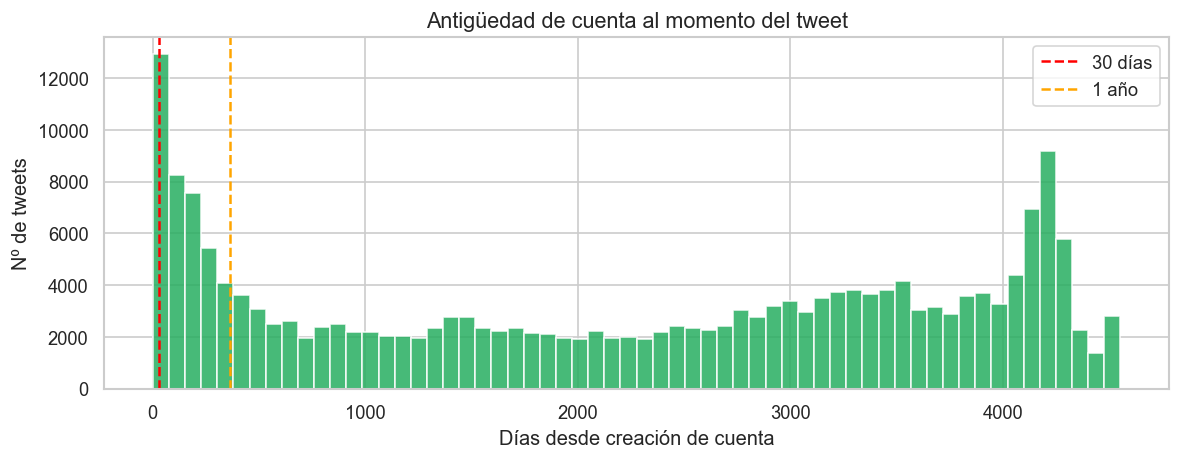

Tweets de cuentas con <= 30 días: 6,871 (3.4%)


In [40]:
if 'account_age_days' in df_sample.columns:
    age = df_sample['account_age_days'].dropna()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(age.clip(upper=age.quantile(0.99)), bins=60, color='#27AE60', edgecolor='white', alpha=0.85)
    ax.axvline(30,  color='red',    linestyle='--', label='30 días')
    ax.axvline(365, color='orange', linestyle='--', label='1 año')
    ax.set_title('Antigüedad de cuenta al momento del tweet', fontsize=13)
    ax.set_xlabel('Días desde creación de cuenta')
    ax.set_ylabel('Nº de tweets')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eda_antiguedad_cuenta.png')
    plt.show()
    nuevas = (age <= 30).sum()
    print(f'Tweets de cuentas con <= 30 días: {nuevas:,} ({nuevas/len(age)*100:.1f}%)')

## 11. Análisis de contenido
### 11.1 Hashtags más frecuentes

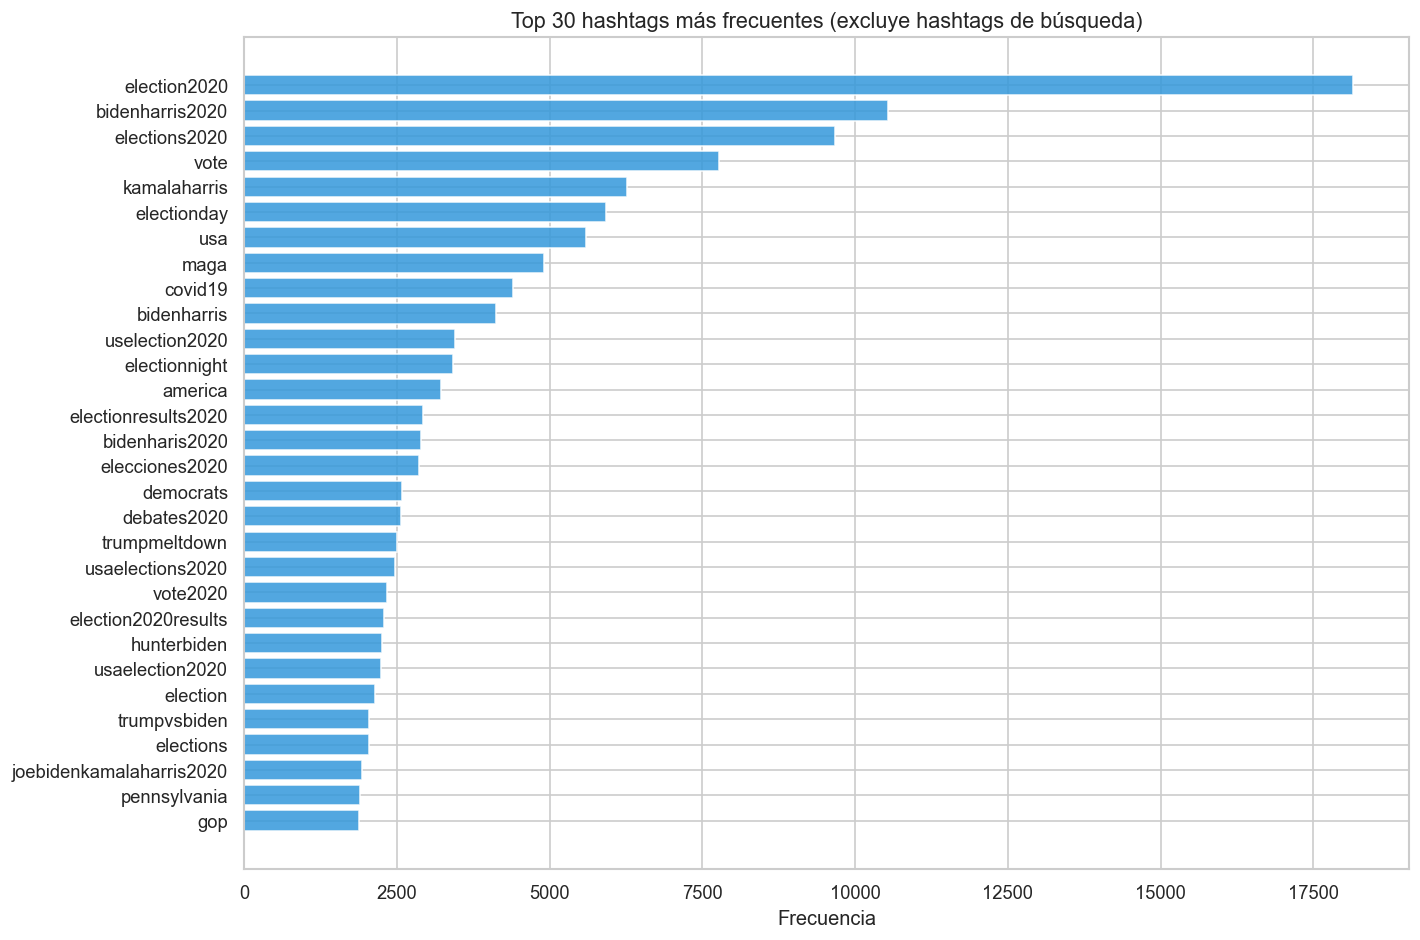

In [41]:
all_hashtags  = [ht for lista in df_sample['hashtags'] for ht in lista]
hashtag_counts = Counter(all_hashtags)
exclude = {'donaldtrump', 'trump', 'joebiden', 'biden', 'trump2020', 'biden2020'}
top_ht  = [(k, v) for k, v in hashtag_counts.most_common(50) if k not in exclude][:30]

labels, values = zip(*top_ht)
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(labels, values, color='#3498DB', alpha=0.85)
ax.invert_yaxis()
ax.set_title('Top 30 hashtags más frecuentes (excluye hashtags de búsqueda)', fontsize=13)
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_top_hashtags.png')
plt.show()

### 11.3 Distribución de likes y retweets

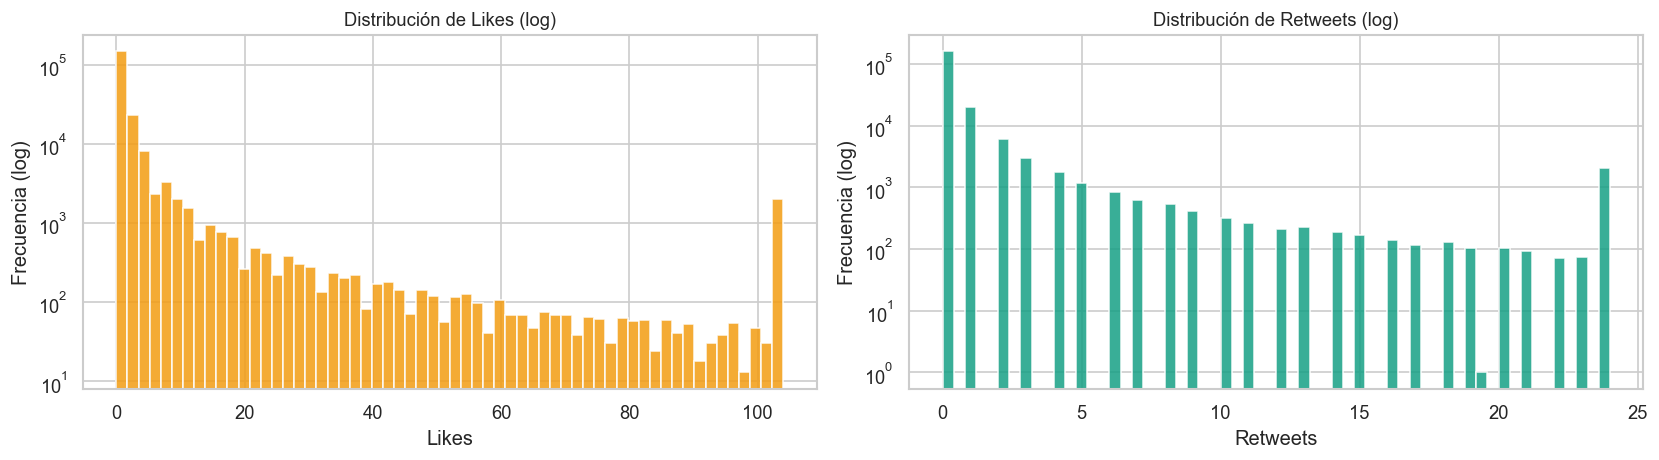

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color, label in [
    (axes[0], 'likes',         '#F39C12', 'Likes'),
    (axes[1], 'retweet_count', '#16A085', 'Retweets')
]:
    data      = df_sample[col].dropna()
    data_clip = data.clip(upper=data.quantile(0.99))
    ax.hist(data_clip, bins=60, color=color, edgecolor='white', alpha=0.85, log=True)
    ax.set_title(f'Distribución de {label} (log)', fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia (log)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_likes_retweets.png')
plt.show()

## 12. Señales de coordinación preliminares
### 12.1 Cuentas que tuitean en múltiples ventanas de burst

In [44]:
# burst_df = df_sample[df_sample['tweets_in_window'] >= p95]
# burst_user_count = burst_df.groupby('user_id')['hour_window'].nunique().reset_index()
# burst_user_count.columns = ['user_id', 'burst_windows_count']

# fig, ax = plt.subplots(figsize=(10, 4))
# ax.hist(burst_user_count['burst_windows_count'], bins=40, color='#C0392B', edgecolor='white', alpha=0.85, log=True)
# ax.set_title('Nº de ventanas burst en que aparece cada cuenta', fontsize=13)
# ax.set_xlabel('Ventanas de burst')
# ax.set_ylabel('Nº de cuentas (log)')
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / 'eda_cuentas_burst.png')
# plt.show()

# multi_burst = burst_user_count[burst_user_count['burst_windows_count'] >= 5]
# print(f'Cuentas en >= 5 ventanas de burst: {len(multi_burst):,}')
# print(burst_user_count.sort_values('burst_windows_count', ascending=False).head(10).to_string(index=False))

### 12.2 Correlación entre variables numéricas

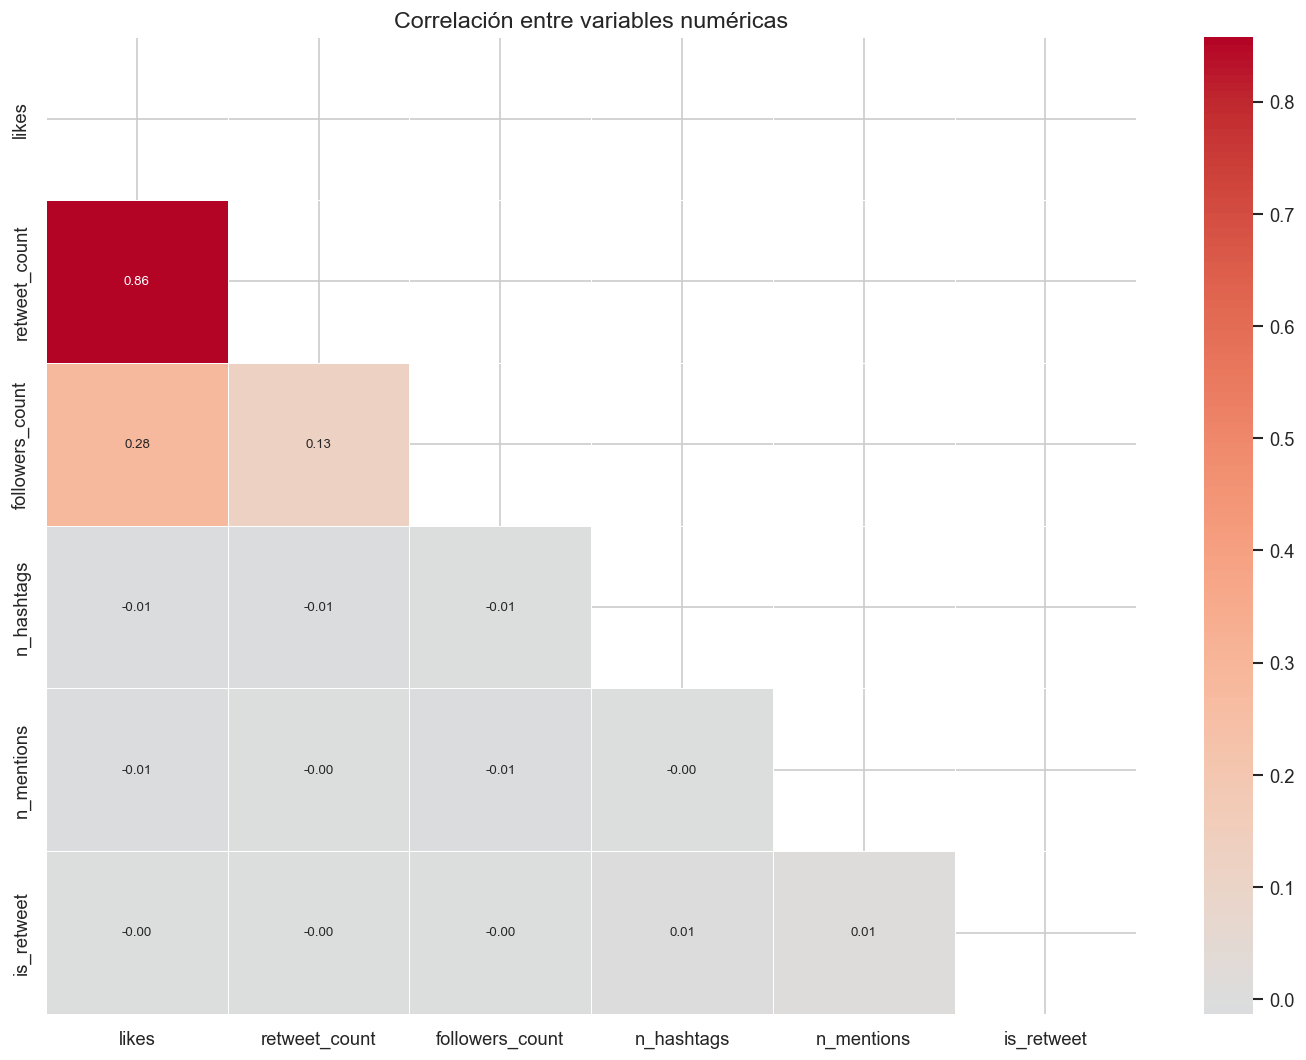

In [45]:
corr_cols = [c for c in [
    'likes', 'retweet_count', 'followers_count', 'n_hashtags',
    'n_mentions', 'is_retweet', 'total_tweets', 'retweet_ratio',
    'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window'
] if c in df_sample.columns]

corr = df_sample[corr_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlación entre variables numéricas', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_correlacion.png')
plt.show()

### 12.3 Actividad de las top 10 cuentas por volumen

In [47]:
# top_users  = df_sample.groupby('user_id').size().nlargest(10).index
# top_df     = df_sample[df_sample['user_id'].isin(top_users)].copy()
# top_df['user_label'] = top_df['user_screen_name'].fillna(top_df['user_id'].astype(str))

# activity = top_df.groupby(['user_label', 'date']).size().reset_index(name='tweets')
# activity['date'] = pd.to_datetime(activity['date'])

# fig, ax = plt.subplots(figsize=(14, 5))
# for user in activity['user_label'].unique():
#     d = activity[activity['user_label'] == user]
#     ax.plot(d['date'], d['tweets'], marker='o', markersize=3, linewidth=1.2, label=str(user))

# ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
# ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
# plt.xticks(rotation=45)
# ax.set_title('Actividad diaria — Top 10 cuentas por volumen', fontsize=13)
# ax.set_xlabel('Fecha')
# ax.set_ylabel('Tweets por día')
# ax.legend(fontsize=7, ncol=2)
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / 'eda_top_cuentas_actividad.png')
# plt.show()

---
## Pendientes
- [ ] Completar tabla de hallazgos con observaciones reales
- [ ] Integrar `bot_detection_data.csv` en A6
- [ ] Definir umbral definitivo de burst (P95 vs P99)
- [ ] Pasar `burst_windows` y `multi_burst` como insumo a A5

2026-06-22 21:30:37,602 - INFO - Running pipeline on sample data...
2026-06-22 21:30:37,839 - INFO - Loading cached embeddings from embedding_cache\embeddings_bbf8c9e9e989e0be5f0be78a4cc774d8.npy
2026-06-22 21:30:40,885 - INFO - Dataset large (1522944), computing similarity pairs on a sample.
2026-06-22 21:30:40,887 - INFO - Sampling 200000 points for similarity search (total 1522944)
2026-06-22 21:31:53,202 - INFO - Generated 20 similarity pairs.
2026-06-22 21:31:53,203 - INFO -   671198 <-> 822008: 1.9191
2026-06-22 21:31:53,203 - INFO -   671198 <-> 989720: 1.8545
2026-06-22 21:31:53,206 - INFO -   272267 <-> 522661: 1.8428
2026-06-22 21:31:53,207 - INFO -   272267 <-> 989720: 1.8412
2026-06-22 21:31:53,209 - INFO -   4882 <-> 671198: 1.8263
2026-06-22 21:31:53,861 - INFO - --- KMeans ---
2026-06-22 22:59:44,349 - INFO - Auto-determined KMeans clusters: 15
2026-06-22 23:07:50,296 - INFO - KMeans: 15 clusters
2026-06-22 23:07:50,297 - INFO - --- HDBSCAN ---
2026-06-22 23:07:50,298 - 

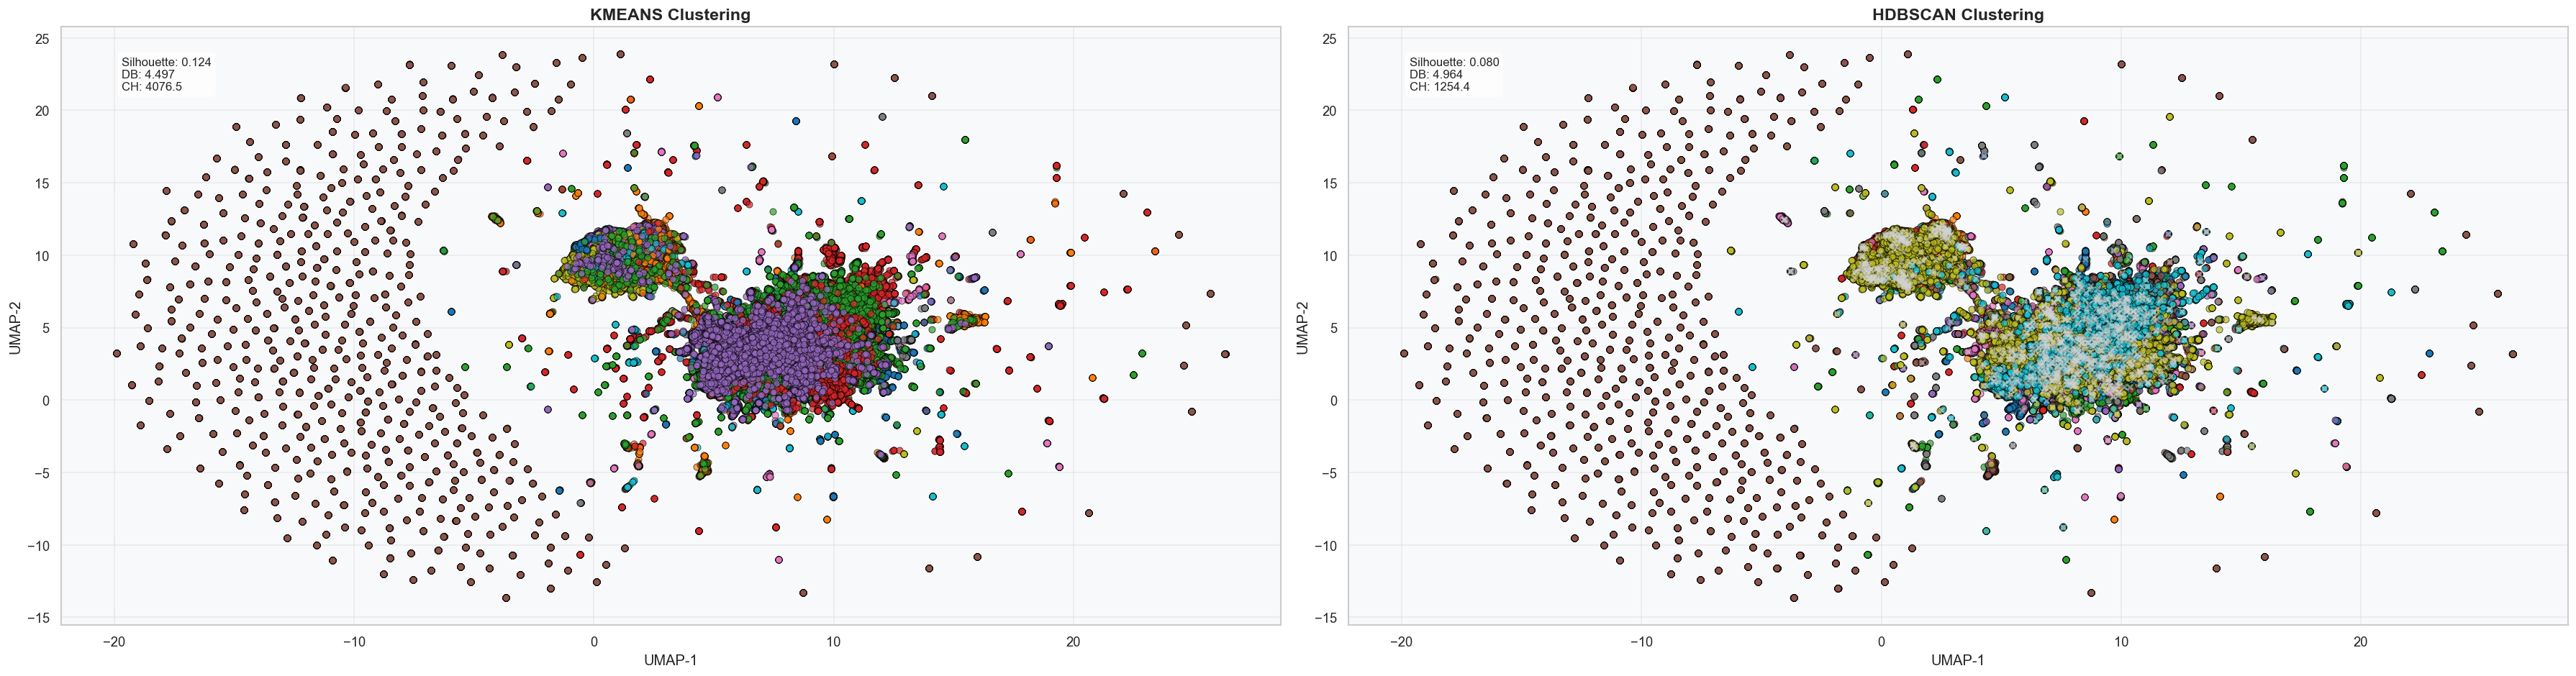

2026-06-22 23:43:14,214 - INFO - 
2026-06-22 23:43:14,215 - INFO - EVALUATION METRICS COMPARISON
2026-06-22 23:43:14,216 - INFO - ============================================================
2026-06-22 23:43:14,235 - INFO - 
         silhouette  davies_bouldin  calinski_harabasz
kmeans     0.123510        4.497365        4076.539819
hdbscan    0.079965        4.964107        1254.371452


In [53]:
"""
Text clustering pipeline – optimised for large datasets.
Supports KMeans, HDBSCAN, and (for small datasets) Agglomerative clustering.
Includes embedding caching, approximate nearest neighbours, and robust evaluation.
"""

import os
import json
import logging
import warnings
from typing import List, Tuple, Optional, Dict, Any, Union
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer

# Optional imports
try:
    import hdbscan
except ImportError:
    hdbscan = None

try:
    import umap
except ImportError:
    umap = None

try:
    import faiss
except ImportError:
    faiss = None

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)


# ----------------------------------------------------------------------
# Configuration (tweak for your hardware)
# ----------------------------------------------------------------------
class Config:
    # Embedding
    EMBEDDING_MODEL = "all-MiniLM-L6-v2"
    EMBEDDING_BATCH_SIZE = 64

    # For large datasets: use random samples for expensive operations
    SAMPLE_SIZE_FOR_SIMILARITY = 200000      # if n > this, similarity pairs are computed on a sample
    SAMPLE_SIZE_FOR_EVALUATION = 200000      # for silhouette etc.
    SAMPLE_SIZE_FOR_VISUALIZATION = 200000   # for UMAP/t-SNE projection
    MAX_ROWS_FOR_AGGLOMERATIVE = 200000     # skip Agglomerative if n > this

    # Clustering defaults
    KMEANS_N_CLUSTERS = None               # if None, auto-determine
    KMEANS_RANDOM_STATE = 42
    KMEANS_N_INIT = 10

    HDBSCAN_MIN_CLUSTER_SIZE = 5
    HDBSCAN_METRIC = "euclidean"
    HDBSCAN_APPROX_MIN_SPAN_TREE = True    # use pynndescent for speed
    HDBSCAN_GEN_MIN_SPAN_TREE = False      # save memory
    HDBSCAN_CORE_DIST_N_JOBS = -1          # use all CPU cores

    # Fast HDBSCAN sampling mode: cluster a subset and classify the rest
    # Set to True for datasets > 50k rows (automatically applied)
    FAST_HDBSCAN_SAMPLE_SIZE = 10000       # number of points to cluster with HDBSCAN
    FAST_HDBSCAN_USE_SAMPLING = True       # enable automatic sampling

    # Approximate nearest neighbours (FAISS) for similarity pairs
    USE_FAISS = True if faiss is not None else False
    FAISS_INDEX_TYPE = "IVF100,SQ8" if faiss else None   # for large scale
    SIMILARITY_TOP_K = 20                # number of top similar pairs to return

    # Visualisation
    USE_UMAP = True if umap is not None else False   # fallback to t-SNE
    UMAP_N_NEIGHBORS = 15
    UMAP_MIN_DIST = 0.1

    # Paths for caching
    CACHE_DIR = Path("./embedding_cache")
    CACHE_DIR.mkdir(exist_ok=True)


# ----------------------------------------------------------------------
# 1. Embeddings with caching
# ----------------------------------------------------------------------
def get_embeddings(
    df: pd.DataFrame,
    text_column: str = "text_clean",
    model_name: str = Config.EMBEDDING_MODEL,
    force_recompute: bool = False,
) -> np.ndarray:
    """
    Load or create embeddings for the text column.
    Caches them as a .npy file based on a hash of the text content.
    """
    # Create a unique cache key based on the text content and model name
    texts = df[text_column].astype(str).tolist()
    # Simple hash of concatenated texts (could be slow for huge df; use a sample for hash?)
    # Better: use a hash of the first few lines + row count + model name
    import hashlib
    sample = "".join(texts[:10])  # not perfect but fast
    content_hash = hashlib.md5((sample + str(len(texts)) + model_name).encode()).hexdigest()
    cache_file = Config.CACHE_DIR / f"embeddings_{content_hash}.npy"

    if cache_file.exists() and not force_recompute:
        logger.info(f"Loading cached embeddings from {cache_file}")
        embeddings = np.load(cache_file)
        if len(embeddings) == len(df):
            return embeddings
        else:
            logger.warning("Cached embeddings size mismatch; recomputing.")

    logger.info(f"Creating embeddings for {len(texts)} texts using {model_name}...")
    model = SentenceTransformer(model_name)
    embeddings = model.encode(
        texts,
        batch_size=Config.EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    np.save(cache_file, embeddings)
    logger.info(f"Embeddings saved to {cache_file}")
    return embeddings


# ----------------------------------------------------------------------
# 2. Similarity pairs (using approximate nearest neighbours)
# ----------------------------------------------------------------------
def generate_similarity_pairs(
    embeddings: np.ndarray,
    top_k: int = Config.SIMILARITY_TOP_K,
    threshold: Optional[float] = None,
    sample_size: Optional[int] = None,
) -> List[Tuple[int, int, float]]:
    """
    Generate similar pairs using approximate nearest neighbours (FAISS if available,
    else sklearn's NearestNeighbors). For large datasets, operate on a random sample
    if sample_size is given.

    Args:
        embeddings: Array of shape (n, d).
        top_k: Number of top similar pairs to return (overall).
        threshold: Minimum similarity to keep a pair (overridden by top_k).
        sample_size: If provided, randomly sample this many points to find pairs.

    Returns:
        List of tuples (i, j, cosine_similarity), sorted descending.
    """
    n = len(embeddings)
    if sample_size is not None and n > sample_size:
        logger.info(f"Sampling {sample_size} points for similarity search (total {n})")
        indices = np.random.choice(n, size=sample_size, replace=False)
        emb_subset = embeddings[indices]
        # We'll map indices back to original indices later
    else:
        indices = np.arange(n)
        emb_subset = embeddings

    # Normalise for cosine similarity
    emb_norm = normalize(emb_subset, norm='l2')

    # Use FAISS if available and configured
    if Config.USE_FAISS and faiss is not None:
        return _faiss_similarity_pairs(emb_norm, indices, top_k, threshold)
    else:
        return _sklearn_similarity_pairs(emb_norm, indices, top_k, threshold)


def _faiss_similarity_pairs(emb_norm, indices, top_k, threshold):
    """FAISS-based approximate cosine similarity (inner product on normalized vectors)."""
    n, d = emb_norm.shape
    # Build index
    if n < 1000:
        index = faiss.IndexFlatIP(d)  # exact inner product
    else:
        # Use IVF for approximate
        nlist = min(100, int(np.sqrt(n)))
        quantizer = faiss.IndexFlatIP(d)
        index = faiss.IndexIVFFlat(quantizer, d, nlist)
        index.train(emb_norm)
    index.add(emb_norm)

    # For each point, search for its top neighbours
    k_search = min(top_k * 2, n - 1)  # we'll filter later
    similarities, neighbor_ids = index.search(emb_norm, k_search + 1)  # +1 because self is included

    pairs = []
    for i in range(n):
        for j_idx in range(1, k_search + 1):  # skip self
            j = neighbor_ids[i, j_idx]
            sim = similarities[i, j_idx]
            # Ensure i < j to avoid duplicates and self
            if i < j and (threshold is None or sim >= threshold):
                pairs.append((indices[i], indices[j], float(sim)))
            elif j < i:
                # We might have j < i; we can skip to avoid duplicates, but we'll handle later
                # Better: only add if i < j to keep one pair
                pass

    # Deduplicate and sort
    # Because we might have both (i,j) and (j,i), we enforce order
    unique_pairs = {}
    for i, j, sim in pairs:
        key = (min(i, j), max(i, j))
        if key not in unique_pairs or sim > unique_pairs[key]:
            unique_pairs[key] = sim
    pairs = [(i, j, sim) for (i, j), sim in unique_pairs.items()]
    pairs.sort(key=lambda x: x[2], reverse=True)

    if top_k is not None:
        pairs = pairs[:top_k]
    return pairs


def _sklearn_similarity_pairs(emb_norm, indices, top_k, threshold):
    """Fallback using sklearn's NearestNeighbors (exact but O(n^2) for large n)."""
    n = len(emb_norm)
    if n > 10000:
        logger.warning("Using exact nearest neighbours on a large sample; this may be slow.")
    nn = NearestNeighbors(metric='cosine', algorithm='brute')
    nn.fit(emb_norm)
    k_search = min(top_k * 2, n - 1)
    distances, neighbor_ids = nn.kneighbors(emb_norm, n_neighbors=k_search + 1)
    # distances are cosine distance, similarity = 1 - distance
    pairs = []
    for i in range(n):
        for j_idx in range(1, k_search + 1):
            j = neighbor_ids[i, j_idx]
            sim = 1 - distances[i, j_idx]
            if i < j and (threshold is None or sim >= threshold):
                pairs.append((indices[i], indices[j], float(sim)))
    # Deduplicate and sort
    unique_pairs = {}
    for i, j, sim in pairs:
        key = (min(i, j), max(i, j))
        if key not in unique_pairs or sim > unique_pairs[key]:
            unique_pairs[key] = sim
    pairs = [(i, j, sim) for (i, j), sim in unique_pairs.items()]
    pairs.sort(key=lambda x: x[2], reverse=True)
    if top_k is not None:
        pairs = pairs[:top_k]
    return pairs


# ----------------------------------------------------------------------
# 3. Auto-determine number of clusters (Gap statistic + silhouette)
# ----------------------------------------------------------------------
def gap_statistic(embeddings: np.ndarray, max_clusters: int = 15, n_refs: int = 5, sample_size: int = 5000):
    """
    Compute Gap statistic for KMeans clustering (Tibshirani et al. 2001).
    Uses a random subsample if embeddings is large.
    Reference: https://web.stanford.edu/~hastie/Papers/gap.pdf

    Returns:
        optimal number of clusters (int).
    """
    n = len(embeddings)
    if n <= 2:
        return 1

    if n > sample_size:
        idx = np.random.choice(n, size=sample_size, replace=False)
        emb_sample = embeddings[idx]
    else:
        emb_sample = embeddings

    # Cap max_clusters to n_samples - 1
    max_clusters = min(max_clusters, len(emb_sample) - 1)
    if max_clusters < 2:
        return 1

    K = range(1, max_clusters + 1)

    # Compute within-cluster dispersion for real data
    inertias = []
    for k in K:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(emb_sample)
        inertias.append(km.inertia_)

    # Compute reference distribution (uniform over bounding box)
    ref_inertias = []
    for _ in range(n_refs):
        min_vals = emb_sample.min(axis=0)
        max_vals = emb_sample.max(axis=0)
        ref_data = np.random.uniform(min_vals, max_vals, size=emb_sample.shape)
        ref_inertias_k = []
        for k in K:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            km.fit(ref_data)
            ref_inertias_k.append(km.inertia_)
        ref_inertias.append(ref_inertias_k)
    ref_inertias = np.array(ref_inertias)

    log_inertias = np.log(inertias)
    log_ref = np.log(ref_inertias)
    gap = log_ref.mean(axis=0) - log_inertias
    # Choose k with maximum gap
    optimal_k = np.argmax(gap) + 1
    return optimal_k


def auto_determine_clusters(
    embeddings: np.ndarray,
    method: str = "gap",
    max_clusters: int = 15,
    sample_size: int = Config.SAMPLE_SIZE_FOR_EVALUATION,
) -> int:
    """
    Determine optimal number of clusters using either 'gap' (Gap statistic) or 'silhouette'
    (on a subsample). Returns an integer between 2 and max_clusters (or 1 if too few samples).
    """
    n = len(embeddings)
    if n <= 2:
        return 1

    # Cap max_clusters to n-1
    max_clusters = min(max_clusters, n - 1)
    if max_clusters < 2:
        return 1

    if method == "gap":
        k = gap_statistic(embeddings, max_clusters, sample_size=sample_size)
        # Ensure k is within [2, max_clusters]
        return max(2, min(k, max_clusters))
    elif method == "silhouette":
        if n > sample_size:
            idx = np.random.choice(n, size=sample_size, replace=False)
            emb_sample = embeddings[idx]
        else:
            emb_sample = embeddings
        K = range(2, min(max_clusters, len(emb_sample) - 1) + 1)
        if len(K) == 0:
            return 1
        best_k = 2
        best_score = -1
        for k in K:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = km.fit_predict(emb_sample)
            if len(set(labels)) > 1:
                score = silhouette_score(emb_sample, labels, metric='cosine')
                if score > best_score:
                    best_score = score
                    best_k = k
        return best_k
    else:
        raise ValueError("method must be 'gap' or 'silhouette'")


# ----------------------------------------------------------------------
# 4. Fast HDBSCAN sampling (for large datasets)
# ----------------------------------------------------------------------
def fast_hdbscan_sampling(
    embeddings: np.ndarray,
    sample_size: int = Config.FAST_HDBSCAN_SAMPLE_SIZE,
    min_cluster_size: int = Config.HDBSCAN_MIN_CLUSTER_SIZE,
    **hdbscan_kwargs
) -> np.ndarray:
    """
    Runs HDBSCAN on a random subset, then classifies the rest using a KNN classifier.
    This is orders of magnitude faster for > 50k rows.

    Args:
        embeddings: Full embedding array.
        sample_size: Number of points to cluster with HDBSCAN.
        min_cluster_size: Passed to HDBSCAN.
        **hdbscan_kwargs: Additional parameters for HDBSCAN.

    Returns:
        Array of cluster labels for all points.
    """
    n = len(embeddings)
    if n <= sample_size:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            approx_min_span_tree=Config.HDBSCAN_APPROX_MIN_SPAN_TREE,
            gen_min_span_tree=Config.HDBSCAN_GEN_MIN_SPAN_TREE,
            core_dist_n_jobs=Config.HDBSCAN_CORE_DIST_N_JOBS,
            **hdbscan_kwargs
        )
        return clusterer.fit_predict(embeddings)

    logger.info(f"Fast HDBSCAN sampling {sample_size} points out of {n}...")
    idx = np.random.choice(n, size=sample_size, replace=False)
    sample_emb = embeddings[idx]

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        approx_min_span_tree=Config.HDBSCAN_APPROX_MIN_SPAN_TREE,
        gen_min_span_tree=Config.HDBSCAN_GEN_MIN_SPAN_TREE,
        core_dist_n_jobs=Config.HDBSCAN_CORE_DIST_N_JOBS,
        **hdbscan_kwargs
    )
    sample_labels = clusterer.fit_predict(sample_emb)

    # Train KNN on non-noise points
    mask = sample_labels != -1
    if mask.sum() == 0:
        logger.warning("All sampled points are noise; returning all noise.")
        return np.full(n, -1)

    knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
    knn.fit(sample_emb[mask], sample_labels[mask])

    full_labels = np.full(n, -1)
    full_labels[~np.isin(np.arange(n), idx)] = knn.predict(embeddings[~np.isin(np.arange(n), idx)])
    full_labels[idx] = sample_labels
    logger.info(f"Fast HDBSCAN done: {len(set(full_labels)) - (1 if -1 in full_labels else 0)} clusters, {(full_labels == -1).sum()} noise.")
    return full_labels


# ----------------------------------------------------------------------
# 5. Clustering (with auto-skip of Agglomerative for large data)
# ----------------------------------------------------------------------
def apply_clustering(
    df: pd.DataFrame,
    embeddings: np.ndarray,
    methods: List[str] = ("kmeans", "hdbscan", "agglomerative"),
    kmeans_params: Optional[Dict] = None,
    hdbscan_params: Optional[Dict] = None,
    agglomerative_params: Optional[Dict] = None,
    auto_determine: bool = True,
    use_fast_hdbscan: Optional[bool] = None,   # if None, auto-decide based on n
) -> pd.DataFrame:
    """
    Apply clustering methods to the embeddings. Adds cluster columns to df.
    For Agglomerative, if len(df) > Config.MAX_ROWS_FOR_AGGLOMERATIVE, it is skipped.
    """
    n = len(df)
    df = df.copy()

    # KMeans
    if "kmeans" in methods:
        logger.info("--- KMeans ---")
        params = kmeans_params or {}
        n_clusters = params.get("n_clusters")
        if n_clusters is None and auto_determine:
            n_clusters = auto_determine_clusters(embeddings, method="gap")
            logger.info(f"Auto-determined KMeans clusters: {n_clusters}")
        elif n_clusters is None:
            n_clusters = 5
        # Safety cap: n_clusters must be <= n-1
        if n_clusters >= n:
            n_clusters = max(1, n - 1)
            logger.warning(f"Capped n_clusters to {n_clusters} (must be < n_samples).")
        km = KMeans(
            n_clusters=n_clusters,
            random_state=params.get("random_state", Config.KMEANS_RANDOM_STATE),
            n_init=params.get("n_init", Config.KMEANS_N_INIT),
            max_iter=params.get("max_iter", 300),
        )
        df["cluster_kmeans"] = km.fit_predict(embeddings)
        logger.info(f"KMeans: {n_clusters} clusters")

    # HDBSCAN
    if "hdbscan" in methods:
        if hdbscan is None:
            logger.warning("HDBSCAN not installed; skipping.")
        else:
            logger.info("--- HDBSCAN ---")
            params = hdbscan_params or {}
            min_cluster_size = params.get("min_cluster_size", Config.HDBSCAN_MIN_CLUSTER_SIZE)
            metric = params.get("metric", Config.HDBSCAN_METRIC)

            # Decide whether to use fast sampling
            if use_fast_hdbscan is None:
                use_fast = Config.FAST_HDBSCAN_USE_SAMPLING and n > Config.FAST_HDBSCAN_SAMPLE_SIZE
            else:
                use_fast = use_fast_hdbscan

            if use_fast and n > Config.FAST_HDBSCAN_SAMPLE_SIZE:
                logger.info("Using fast HDBSCAN sampling mode (clustering subset + KNN).")
                labels = fast_hdbscan_sampling(
                    embeddings,
                    sample_size=Config.FAST_HDBSCAN_SAMPLE_SIZE,
                    min_cluster_size=min_cluster_size,
                    **{k: v for k, v in params.items() if k not in ['min_cluster_size', 'metric']}
                )
            else:
                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=min_cluster_size,
                    min_samples=params.get("min_samples"),
                    metric=metric,
                    cluster_selection_method=params.get("cluster_selection_method", "eom"),
                    prediction_data=params.get("prediction_data", True),
                    approx_min_span_tree=params.get("approx_min_span_tree", Config.HDBSCAN_APPROX_MIN_SPAN_TREE),
                    gen_min_span_tree=params.get("gen_min_span_tree", Config.HDBSCAN_GEN_MIN_SPAN_TREE),
                    core_dist_n_jobs=params.get("core_dist_n_jobs", Config.HDBSCAN_CORE_DIST_N_JOBS),
                )
                labels = clusterer.fit_predict(embeddings)

            df["cluster_hdbscan"] = labels
            n_clusters_hdb = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = (labels == -1).sum()
            logger.info(f"HDBSCAN: {n_clusters_hdb} clusters + {n_noise} noise")

    # Agglomerative (only if not too large)
    if "agglomerative" in methods:
        if n > Config.MAX_ROWS_FOR_AGGLOMERATIVE:
            logger.warning(f"Agglomerative clustering skipped because n={n} > {Config.MAX_ROWS_FOR_AGGLOMERATIVE}.")
        else:
            logger.info("--- Agglomerative clustering ---")
            params = agglomerative_params or {}
            n_clusters = params.get("n_clusters")
            if n_clusters is None and auto_determine:
                n_clusters = auto_determine_clusters(embeddings, method="gap")
                logger.info(f"Auto-determined Agglomerative clusters: {n_clusters}")
            elif n_clusters is None:
                n_clusters = 5
            # Safety cap
            if n_clusters >= n:
                n_clusters = max(1, n - 1)
                logger.warning(f"Capped n_clusters to {n_clusters}.")
            agg = AgglomerativeClustering(
                n_clusters=n_clusters,
                linkage=params.get("linkage", "ward"),
                metric=params.get("metric", "euclidean"),
            )
            df["cluster_agglomerative"] = agg.fit_predict(embeddings)
            logger.info(f"Agglomerative: {n_clusters} clusters")

    return df


# ----------------------------------------------------------------------
# 6. Evaluation metrics (on sample)
# ----------------------------------------------------------------------
def evaluate_clustering(
    embeddings: np.ndarray,
    labels: np.ndarray,
    sample_size: int = Config.SAMPLE_SIZE_FOR_EVALUATION,
) -> Dict[str, float]:
    """
    Compute silhouette, Davies-Bouldin, and Calinski-Harabasz scores.
    If labels contain noise (-1), those points are excluded for metrics that require all points assigned.
    For large data, evaluate on a random sample.
    """
    n = len(embeddings)
    if n > sample_size:
        idx = np.random.choice(n, size=sample_size, replace=False)
        emb_sample = embeddings[idx]
        labels_sample = labels[idx]
    else:
        emb_sample = embeddings
        labels_sample = labels

    # Remove noise (if any) – only for metrics that require all points in clusters
    mask = labels_sample != -1
    if not mask.any():
        return {"silhouette": -1, "davies_bouldin": -1, "calinski_harabasz": -1}
    emb_clean = emb_sample[mask]
    labels_clean = labels_sample[mask]

    # Need at least 2 clusters and 2 samples per cluster for silhouette
    n_clusters = len(set(labels_clean))
    if n_clusters < 2 or len(labels_clean) < n_clusters:
        return {"silhouette": -1, "davies_bouldin": -1, "calinski_harabasz": -1}

    try:
        sil = silhouette_score(emb_clean, labels_clean, metric='cosine')
    except:
        sil = -1
    try:
        db = davies_bouldin_score(emb_clean, labels_clean)
    except:
        db = -1
    try:
        ch = calinski_harabasz_score(emb_clean, labels_clean)
    except:
        ch = -1
    return {"silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch}


# ----------------------------------------------------------------------
# 7. Visualisation (UMAP/t-SNE, cluster statistics, metric comparison)
# ----------------------------------------------------------------------
def visualize_clusters(
    df: pd.DataFrame,
    embeddings: np.ndarray,
    methods_to_plot: List[str] = ("kmeans", "hdbscan"),
    figsize: Tuple[int, int] = (15, 8),
) -> plt.Figure:
    """
    2D projection using UMAP (or t-SNE fallback) and plot clusters.
    Also prints a table of evaluation metrics for each method.
    """
    n = len(df)
    # Sample for visualisation if too large
    if n > Config.SAMPLE_SIZE_FOR_VISUALIZATION:
        idx = np.random.choice(n, size=Config.SAMPLE_SIZE_FOR_VISUALIZATION, replace=False)
        emb_sample = embeddings[idx]
        df_sample = df.iloc[idx].copy()
        logger.info(f"Using {Config.SAMPLE_SIZE_FOR_VISUALIZATION} points for visualisation.")
    else:
        emb_sample = embeddings
        df_sample = df

    # Reduce dimensions
    logger.info("Reducing dimensions for visualisation...")
    if Config.USE_UMAP and umap is not None:
        reducer = umap.UMAP(
            n_neighbors=Config.UMAP_N_NEIGHBORS,
            min_dist=Config.UMAP_MIN_DIST,
            random_state=42,
        )
        coords = reducer.fit_transform(emb_sample)
    else:
        # t-SNE – slower but reliable
        tsne = TSNE(
            n_components=2,
            random_state=42,
            perplexity=min(30, len(emb_sample) - 1),
            max_iter=1000,
            learning_rate="auto",
            init="pca",
        )
        coords = tsne.fit_transform(emb_sample)

    # Create subplots
    n_methods = len(methods_to_plot)
    fig, axes = plt.subplots(1, n_methods, figsize=(figsize[0] * n_methods, figsize[1]))
    if n_methods == 1:
        axes = [axes]

    # Evaluate each method and collect metrics
    metrics_dict = {}

    for idx, method in enumerate(methods_to_plot):
        cluster_col = f"cluster_{method}"
        if cluster_col not in df_sample.columns:
            logger.warning(f"Column {cluster_col} not found; skipping.")
            continue

        labels = df_sample[cluster_col].values
        # Remove noise for colour mapping (but keep for plotting)
        unique_clusters = sorted(set(labels))
        if method == "hdbscan":
            # Treat -1 as noise
            unique_no_noise = [c for c in unique_clusters if c != -1]
        else:
            unique_no_noise = unique_clusters

        # Compute metrics on the full dataset (or sample) using the original df and embeddings
        # We'll compute on the full embeddings but with sampling if needed
        full_labels = df[cluster_col].values
        metrics = evaluate_clustering(embeddings, full_labels)
        metrics_dict[method] = metrics
        logger.info(f"Metrics for {method}: {metrics}")

        # Palette
        palette = sns.color_palette("tab10", len(unique_no_noise))

        ax = axes[idx]
        # Plot each cluster
        for i, cluster_id in enumerate(unique_no_noise):
            mask = labels == cluster_id
            color = palette[i % len(palette)]
            ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                c=[color],
                label=f"Cluster {cluster_id}",
                alpha=0.7,
                s=30,
                edgecolors='black',
                linewidth=0.5,
            )
        # Plot noise (HDBSCAN)
        if method == "hdbscan" and -1 in unique_clusters:
            noise_mask = labels == -1
            ax.scatter(
                coords[noise_mask, 0],
                coords[noise_mask, 1],
                c='lightgray',
                label='Noise',
                alpha=0.5,
                s=20,
                marker='x',
            )

        ax.set_title(f"{method.upper()} Clustering", fontsize=14, fontweight='bold')
        ax.set_xlabel("UMAP-1" if Config.USE_UMAP else "t-SNE-1")
        ax.set_ylabel("UMAP-2" if Config.USE_UMAP else "t-SNE-2")
        # Add metrics as text box
        textstr = f"Silhouette: {metrics['silhouette']:.3f}\nDB: {metrics['davies_bouldin']:.3f}\nCH: {metrics['calinski_harabasz']:.1f}"
        ax.text(
            0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        )
        #ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, framealpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#f8f9fa')

    plt.tight_layout()
    plt.show()

    # Print comparison table
    logger.info("\n" + "="*60)
    logger.info("EVALUATION METRICS COMPARISON")
    logger.info("="*60)
    df_metrics = pd.DataFrame(metrics_dict).T
    logger.info("\n" + df_metrics.to_string())

    return fig


# ----------------------------------------------------------------------
# 8. Full pipeline (example usage)
# ----------------------------------------------------------------------
def run_pipeline(
    df: pd.DataFrame,
    text_column: str = "text_clean",
    methods: List[str] = ("kmeans", "hdbscan", "agglomerative"),
    compute_similarity: bool = True,
):
    """
    Full pipeline: embeddings, similarity pairs, clustering, evaluation, visualisation.
    """
    # Step 1: Embeddings
    embeddings = get_embeddings(df, text_column)

    # Step 2: Similarity pairs (only if requested and dataset not too huge)
    if compute_similarity:
        n = len(df)
        if n > Config.SAMPLE_SIZE_FOR_SIMILARITY:
            logger.info(f"Dataset large ({n}), computing similarity pairs on a sample.")
            pairs = generate_similarity_pairs(embeddings, sample_size=Config.SAMPLE_SIZE_FOR_SIMILARITY)
        else:
            pairs = generate_similarity_pairs(embeddings)
        logger.info(f"Generated {len(pairs)} similarity pairs.")
        # Print top 5
        for i, j, sim in pairs[:5]:
            logger.info(f"  {i} <-> {j}: {sim:.4f}")
    else:
        pairs = []

    # Step 3: Clustering
    df_clustered = apply_clustering(df, embeddings, methods)

    # Step 4: Visualise
    visualize_clusters(df_clustered, embeddings, methods_to_plot=methods)

    return df_clustered, pairs, embeddings


# ----------------------------------------------------------------------
# Example usage (with a more varied sample, including the problematic ones)
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # Create dummy data that triggered the error originally
    data = {
        "text_clean": [
            "I love machine learning and AI.",
            "Deep learning is a subset of machine learning.",
            "Natural language processing is fascinating.",
            "I enjoy playing chess and strategy games.",
            "Football is the most popular sport worldwide.",
            "Basketball requires both skill and athleticism.",
            "Python is a great language for data science.",
            "R is also used for statistical analysis.",
            "The weather today is sunny and warm.",
            "It might rain later in the evening.",
            "you use a fictional one, though, you should NOT expect all controllers to immediately understand what yours is and how it should be verbalized.",
            "Every system can be abused, doesnt mean you disable it",
            "I usually remember when I turn off the engines and everything goes black",
            "if it's the two at the bottom left edge of that screenshot, it's because one is not correlated",
            "different products display different levels differently"
        ]
    }
    logger.info("Running pipeline on sample data...")
    # We'll run only KMeans and HDBSCAN for speed (Agglomerative may be slow for > 10k)
    df_result, pairs_result, emb = run_pipeline(df, compute_similarity=True, methods=["kmeans", "hdbscan"])

In [49]:
print(df["created_at"][2025])
print(df.dtypes)

NaT
tweet_id                            str
text                                str
created_at          datetime64[us, UTC]
user_id                             str
user_screen_name                    str
followers_count                 float64
user_join_date      datetime64[us, UTC]
likes                           float64
retweet_count                   float64
source                              str
user_location                       str
state                               str
country                             str
candidate                           str
account_age_days                float64
hashtags                         object
mentions                         object
is_retweet                        int64
n_hashtags                        int64
n_mentions                        int64
text_clean                          str
total_tweets_x                  float64
total_retweets_x                float64
avg_likes_x                     float64
avg_rt_x                        floa

In [50]:
import pandas as pd
import numpy as np
from typing import List, Union, Optional

def analyze_cluster_times(
    df: pd.DataFrame,
    cluster_cols: Union[str, List[str]],
    time_col: str = "created_at",
    time_unit: str = "seconds",
    compute_pairwise: bool = True,
    max_pairwise_size: int = 5000,
    filter_span_seconds: Optional[float] = None,
) -> pd.DataFrame:
    """
    For each cluster, compute temporal dispersion statistics.
    """
    # Ensure time_col is datetime
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df = df.copy()
        df[time_col] = pd.to_datetime(df[time_col])
        print("check")
    
    valid_mask = df[time_col].notna()
    n_dropped = len(df) - valid_mask.sum()
    if n_dropped > 0:
        logger.info(f"Dropped {n_dropped} rows with NaT in '{time_col}' for temporal analysis.")
    df_clean = df[valid_mask].copy()

    if len(df_clean) == 0:
        logger.warning("No rows with valid timestamps; returning empty DataFrame.")
        return pd.DataFrame()
    
    # Convert to seconds since epoch (as float)
    times_seconds = df_clean[time_col].astype('int64') // 10**6
    print(df_clean[time_col][5], df_clean[time_col][112])
    print(times_seconds[5], times_seconds[112])
    
    # Define time unit factor ONCE (outside the loop)
    unit_factor = {'seconds': 1, 'minutes': 60, 'hours': 3600, 'days': 86400}.get(time_unit, 1)

    if isinstance(cluster_cols, str):
        cluster_cols = [cluster_cols]

    all_results = []

    for col in cluster_cols:
        if col not in df_clean.columns:
            print(f"Warning: column '{col}' not found in DataFrame. Skipping.")
            continue

        grouped = df_clean.groupby(col)
        for cluster_id, group in grouped:
            cluster_times = times_seconds.loc[group.index].values
            n = len(cluster_times)
            if n == 0:
                continue
            # Basic stats (O(n))
            mean_time = np.mean(cluster_times)
            std_time = np.std(cluster_times, ddof=1) if n > 1 else 0.0
            min_time = np.min(cluster_times)
            max_time = np.max(cluster_times)
            span = max_time - min_time
            # Mean pairwise absolute difference (O(n²) if enabled)
            if compute_pairwise and n > 1 and n <= max_pairwise_size:
                diff_matrix = np.abs(cluster_times[:, None] - cluster_times[None, :])
                total_diff = np.sum(diff_matrix) / 2
                mean_pairwise = total_diff / (n * (n - 1) / 2)
            else:
                mean_pairwise = np.nan
            row = {
                'cluster_method': col,
                'cluster_id': cluster_id,
                'count': n,
                'mean_time': mean_time / unit_factor,
                'std_time': std_time / unit_factor,
                'min_time': min_time / unit_factor,
                'max_time': max_time / unit_factor,
                'span': span / unit_factor,
                'mean_pairwise_diff': mean_pairwise / unit_factor if not np.isnan(mean_pairwise) else np.nan,
            }
            all_results.append(row)

    result_df = pd.DataFrame(all_results)
    
    # Apply span filter (convert threshold from seconds to the chosen unit)
    if filter_span_seconds is not None:
        threshold_in_unit = filter_span_seconds / unit_factor
        result_df = result_df[result_df['span'] <= threshold_in_unit]

    return result_df


def get_cluster_rows(
    df: pd.DataFrame,
    cluster_col: str,
    cluster_id: Union[int, List[int], np.integer],
) -> pd.DataFrame:
    """
    Return the rows belonging to specified cluster(s) from a given cluster column.
    Handles both Python ints and NumPy ints (np.int64, etc.).
    """
    # Convert to list if it's a scalar (including NumPy scalars)
    if isinstance(cluster_id, (int, np.integer)):   # <-- FIXED: checks both Python int and NumPy int
        cluster_id = [cluster_id]
    elif isinstance(cluster_id, list):
        pass  # already a list
    else:
        raise TypeError(f"cluster_id must be int, list, or numpy integer, got {type(cluster_id)}")

    # Ensure all elements are Python ints (in case of mixed types)
    cluster_id = [int(c) for c in cluster_id]

    return df[df[cluster_col].isin(cluster_id)]


# ----------------------------------------------------------------------
# Example usage (corrected)
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # Assuming df_result is the output of run_pipeline()
    stats_df = analyze_cluster_times(
        df_result,
        cluster_cols=['cluster_kmeans', 'cluster_hdbscan'],
        time_col='created_at',
        time_unit='seconds',
        compute_pairwise=True,
        max_pairwise_size=2000,
        filter_span_seconds=300000000         # keep clusters where all texts are within 5 seconds
    )

    print("Temporally tight clusters (span <= 5 sec):")
    print(stats_df)

    # Get rows for the first tight cluster
    if not stats_df.empty:
        row = stats_df.iloc[0]
        method = row['cluster_method']
        cluster_id = row['cluster_id']   # This is a numpy.int64; the fixed function handles it
        
        tight_rows = get_cluster_rows(df_result, method, cluster_id)
        print(f"\nRows in cluster {cluster_id} of {method}:")
        print(tight_rows[['text', 'created_at']].head(10))

2026-06-22 21:29:34,011 - INFO - Dropped 35 rows with NaT in 'created_at' for temporal analysis.


2020-10-15 00:00:17+00:00 2020-10-15 00:05:56+00:00
1602720017 1602720356
Temporally tight clusters (span <= 5 sec):
     cluster_method  cluster_id   count     mean_time       std_time  \
0    cluster_kmeans           0  116586  1.604042e+09  633407.777414   
1    cluster_kmeans           1   72803  1.604354e+09  518430.497039   
2    cluster_kmeans           2  176016  1.604083e+09  654659.319202   
3    cluster_kmeans           3  125622  1.604221e+09  604204.987634   
4    cluster_kmeans           4   62508  1.604419e+09  484276.263052   
5    cluster_kmeans           5  139990  1.604156e+09  609550.734812   
6    cluster_kmeans           6  138035  1.604178e+09  563672.994893   
7    cluster_kmeans           7   71492  1.604176e+09  639592.121243   
8    cluster_kmeans           8  135787  1.604408e+09  488576.948121   
9    cluster_kmeans           9  109320  1.604049e+09  638501.899884   
10   cluster_kmeans          10   94875  1.603861e+09  663997.869987   
11   cluster_kmeans

In [51]:
import pandas as pd
import numpy as np
from typing import Optional, Tuple, List

def get_temporally_close_rows(
    df: pd.DataFrame,
    time_col: str = "created_at",
    delta_seconds: float = 5.0,
    min_rows_per_window: int = 2,
    return_original_indices: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Identify rows that belong to temporal bursts (groups of rows close in time).

    For each row, we check if it is within `delta_seconds` (via chained gaps)
    of at least one other row. Rows are grouped into windows; only windows
    with >= `min_rows_per_window` rows are returned.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    time_col : str
        Name of the datetime column.
    delta_seconds : float
        Maximum allowed gap between consecutive timestamps to stay in the same window.
    min_rows_per_window : int
        Minimum number of rows required in a window to be kept.
    return_original_indices : bool
        If True, keep the original DataFrame index as a column ('original_index')
        so you can join back later.

    Returns
    -------
    windows_df : pd.DataFrame
        The rows that belong to time windows (bursts), with an added 'time_window_id' column.
    window_stats : pd.DataFrame
        Summary statistics for each window (window_id, start, end, count, duration, etc.).
    """
    # Make a copy and ensure datetime
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

    # Drop rows with NaT
    valid = df[time_col].notna()
    if not valid.all():
        print(f"Dropping {valid.sum()} rows with NaT in '{time_col}'.")
    df = df[valid].copy()

    if len(df) == 0:
        return pd.DataFrame(), pd.DataFrame()

    # Sort by time
    df_sorted = df.sort_values(time_col).copy()
    times = df_sorted[time_col]

    # Calculate time differences between consecutive rows (in seconds)
    diffs = times.diff().dt.total_seconds()
    # First row has NaN diff; we treat it as the start of a window
    diffs.iloc[0] = 0.0

    # Assign window IDs: when diff > delta_seconds, start a new window
    window_ids = (diffs > delta_seconds).cumsum()
    df_sorted['time_window_id'] = window_ids

    # Compute window sizes
    window_sizes = df_sorted.groupby('time_window_id').size()
    valid_windows = window_sizes[window_sizes >= min_rows_per_window].index

    # Filter rows to only those in valid windows
    windows_df = df_sorted[df_sorted['time_window_id'].isin(valid_windows)].copy()

    # Optionally keep original indices for merging later
    if return_original_indices:
        windows_df['original_index'] = windows_df.index

    # Create summary statistics per window
    stats = (
        windows_df.groupby('time_window_id')
        .agg(
            start=(time_col, 'min'),
            end=(time_col, 'max'),
            count=(time_col, 'size'),
        )
        .reset_index()
    )
    stats['duration_sec'] = (stats['end'] - stats['start']).dt.total_seconds()

    # Optional: include the original row indices in the stats?
    # Not necessary unless you want first/last indices.

    # Reset index for clean output (optional)
    windows_df = windows_df.reset_index(drop=True)

    return windows_df, stats


# ----------------------------------------------------------------------
# Example usage
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # Assuming you have `df_result` from the clustering pipeline
    # Extract temporally close rows (within 5 seconds in connected windows)
    time_windows_df, window_stats = get_temporally_close_rows(
        df_result,
        time_col="created_at",
        delta_seconds=5.0,
        min_rows_per_window=2,
        return_original_indices=True,
    )

    print(f"Found {len(window_stats)} temporal windows (bursts).")
    print("Total rows in these windows:", len(time_windows_df))
    print("\nWindow statistics:")
    print(window_stats.head())

    # To see the actual texts in the first window:
    first_window_id = window_stats.iloc[0]['time_window_id']
    first_window_rows = time_windows_df[time_windows_df['time_window_id'] == first_window_id]
    print(f"\nRows in window {first_window_id}:")
    print(first_window_rows[['text_clean', 'created_at']].head(10))

    # If you want to go back to the original DataFrame and mark which rows are in a time burst:
    df_result['in_time_burst'] = df_result.index.isin(time_windows_df['original_index'])
    print(f"\nFraction of rows in time bursts: {df_result['in_time_burst'].mean():.2%}")

Dropping 1522909 rows with NaT in 'created_at'.
Found 62017 temporal windows (bursts).
Total rows in these windows: 1508346

Window statistics:
   time_window_id                     start                       end  count  \
0               0 2020-10-15 00:00:01+00:00 2020-10-15 00:00:02+00:00      4   
1               2 2020-10-15 00:00:17+00:00 2020-10-15 00:00:44+00:00     19   
2               3 2020-10-15 00:00:55+00:00 2020-10-15 00:00:57+00:00      2   
3               4 2020-10-15 00:01:03+00:00 2020-10-15 00:01:32+00:00     20   
4               5 2020-10-15 00:01:38+00:00 2020-10-15 00:02:42+00:00     38   

   duration_sec  
0           1.0  
1          27.0  
2           2.0  
3          29.0  
4          64.0  

Rows in window 0:
                                          text_clean                created_at
0  dice que solo preocupa por mismo demócrata fue... 2020-10-15 00:00:01+00:00
1  usa 2020 trump contro facebook twitter coprono... 2020-10-15 00:00:01+00:00
2  student 

In [ ]:
df_result.dtypes

tweet_id                            str
text                                str
created_at          datetime64[us, UTC]
user_id                             str
user_screen_name                    str
followers_count                 float64
user_join_date                      str
likes                           float64
retweet_count                   float64
source                              str
user_location                       str
state                               str
country                             str
candidate                           str
hashtags                         object
mentions                         object
is_retweet                        int64
n_hashtags                        int64
n_mentions                        int64
text_clean                          str
cluster_kmeans                    int32
cluster_hdbscan                   int64
in_time_burst                      bool
dtype: object

In [52]:
import pandas as pd
import numpy as np
from typing import List, Optional, Union, Tuple
from sklearn.metrics.pairwise import cosine_similarity
import logging

logger = logging.getLogger(__name__)

def analyze_temporal_semantic_windows(
    df: pd.DataFrame,
    windows_df: pd.DataFrame,
    cluster_col: str = "cluster_hdbscan",
    embedding_col: str = "embeddings",
    min_cluster_purity: float = 0.5,          # minimum fraction to keep a window
    min_avg_similarity: Optional[float] = None, # e.g., 0.7
    max_window_size_for_pairwise: int = 5000,  # skip pairwise if window larger than this
    verbose: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Combine temporal windows with semantic analysis.

    For each time window (from get_temporally_close_rows), compute:
      - Dominant cluster label and its purity (fraction of rows in that cluster)
      - Average pairwise cosine similarity and its standard deviation
      - Count of rows

    Parameters
    ----------
    df : pd.DataFrame
        Original DataFrame that contains the cluster and embedding columns.
        Must have the original index matching the 'original_index' column in windows_df.
    windows_df : pd.DataFrame
        Output from get_temporally_close_rows() with an 'original_index' column.
    cluster_col : str
        Name of the cluster column (e.g., 'cluster_hdbscan').
    embedding_col : str
        Name of the column containing the embedding vectors (list of floats).
    min_cluster_purity : float
        Minimum purity (0-1) required for a window to be kept in the filtered output.
    min_avg_similarity : float or None
        If provided, only keep windows with avg_pairwise_similarity >= this value.
    max_window_size_for_pairwise : int
        Skip pairwise similarity computation for windows larger than this (to avoid O(n²) blowup).
    verbose : bool
        Print progress information.

    Returns
    -------
    filtered_windows_df : pd.DataFrame
        The rows of windows_df that pass the purity and similarity filters.
    window_summary : pd.DataFrame
        Summary statistics for all windows (including those filtered out).
    """
    if windows_df.empty:
        logger.warning("windows_df is empty. Returning empty DataFrames.")
        return pd.DataFrame(), pd.DataFrame()

    # Ensure the windows_df has the original index
    if 'original_index' not in windows_df.columns:
        raise ValueError("windows_df must contain 'original_index' column. "
                         "Set return_original_indices=True in get_temporally_close_rows().")

    # Get the embeddings as a numpy array for fast lookup
    if embedding_col not in df.columns:
        raise ValueError(f"Column '{embedding_col}' not found in df.")
    # Convert embeddings to numpy array (if they are stored as lists)
    embeddings = np.array(df[embedding_col].tolist())

    # Prepare to store results
    all_summaries = []
    kept_window_ids = []

    # Group windows_df by window_id
    grouped = windows_df.groupby('time_window_id')
    total_windows = len(grouped)

    if verbose:
        logger.info(f"Analyzing {total_windows} temporal windows...")

    for window_id, group in grouped:
        # Get original indices of rows in this window
        orig_indices = group['original_index'].values
        count = len(orig_indices)

        # ---- Semantic cluster analysis ----
        cluster_labels = df.loc[orig_indices, cluster_col].values
        # Count occurrences
        unique, counts = np.unique(cluster_labels, return_counts=True)
        if len(unique) == 0:
            continue

        dominant_cluster = unique[np.argmax(counts)]
        purity = np.max(counts) / count

        # ---- Embedding similarity analysis ----
        avg_sim = np.nan
        std_sim = np.nan
        if count > 1:
            emb_window = embeddings[orig_indices]
            # If window is too large, skip pairwise (or sample? We'll skip with a warning)
            if count <= max_window_size_for_pairwise:
                sim_matrix = cosine_similarity(emb_window)
                # Get upper triangle (excluding diagonal)
                upper_tri_indices = np.triu_indices_from(sim_matrix, k=1)
                sim_values = sim_matrix[upper_tri_indices]
                if len(sim_values) > 0:
                    avg_sim = np.mean(sim_values)
                    std_sim = np.std(sim_values)
            else:
                if verbose:
                    logger.warning(f"Window {window_id} has {count} rows, exceeding pairwise limit ({max_window_size_for_pairwise}). Skipping similarity computation.")
                avg_sim = np.nan
                std_sim = np.nan

        # Store summary
        summary_row = {
            'time_window_id': window_id,
            'count': count,
            'dominant_cluster': dominant_cluster,
            'cluster_purity': purity,
            'avg_pairwise_sim': avg_sim,
            'std_pairwise_sim': std_sim,
        }
        all_summaries.append(summary_row)

        # Check filters
        keep = True
        if purity < min_cluster_purity:
            keep = False
        if min_avg_similarity is not None and (np.isnan(avg_sim) or avg_sim < min_avg_similarity):
            keep = False

        if keep:
            kept_window_ids.append(window_id)

    # Create summary DataFrame
    window_summary = pd.DataFrame(all_summaries)

    if verbose:
        logger.info(f"Kept {len(kept_window_ids)} out of {total_windows} windows after filtering.")

    # Filter the original windows_df to only kept windows
    filtered_windows_df = windows_df[windows_df['time_window_id'].isin(kept_window_ids)].copy()

    return filtered_windows_df, window_summary


# ----------------------------------------------------------------------
# Helper to get all rows for a specific window (with text)
# ----------------------------------------------------------------------
def get_rows_for_window(
    df: pd.DataFrame,
    windows_df: pd.DataFrame,
    window_id: int,
    text_col: str = "text_clean",
) -> pd.DataFrame:
    """
    Return the actual rows (with text) for a given time window.
    """
    window_rows = windows_df[windows_df['time_window_id'] == window_id]
    if window_rows.empty:
        return pd.DataFrame()

    orig_indices = window_rows['original_index'].values
    return df.loc[orig_indices, [text_col, 'created_at', 'cluster_kmeans', 'cluster_hdbscan']].copy()


# ----------------------------------------------------------------------
# Full example usage
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # 1. First, get temporal windows (as before)
    time_windows_df, window_stats = get_temporally_close_rows(
        df_result,
        time_col="created_at",
        delta_seconds=5.0,
        min_rows_per_window=2,
        return_original_indices=True,
    )

    # 2. Combine with semantic analysis (using HDBSCAN clusters)
    filtered_windows, summary = analyze_temporal_semantic_windows(
        df=df_result,
        windows_df=time_windows_df,
        cluster_col="cluster_hdbscan",       # or "cluster_kmeans"
        embedding_col="embeddings",
        min_cluster_purity=0.7,              # at least 70% of rows in same cluster
        min_avg_similarity=0.6,              # average cosine similarity >= 0.6
        max_window_size_for_pairwise=5000,
        verbose=True,
    )

    print("\n--- Summary of all temporal windows (with semantic stats) ---")
    print(summary.head(10))

    print(f"\nKept {len(filtered_windows)} rows in semantically cohesive time windows.")

    # 3. Inspect the first kept window
    if not filtered_windows.empty:
        first_window_id = filtered_windows.iloc[0]['time_window_id']
        print(f"\n--- Rows in the first kept window (ID={first_window_id}) ---")
        first_window_rows = get_rows_for_window(df_result, filtered_windows, first_window_id)
        print(first_window_rows[['text_clean', 'created_at']].head(10))

    # 4. Optionally, mark these rows in your original DataFrame
    df_result['in_semantic_time_burst'] = df_result.index.isin(filtered_windows['original_index'])
    print(f"\nFraction of rows in semantic time bursts: {df_result['in_semantic_time_burst'].mean():.2%}")

Dropping 1522909 rows with NaT in 'created_at'.


ValueError: Column 'embeddings' not found in df.

In [ ]:
df_result.dtypes

tweet_id                                  str
text                                      str
created_at                datetime64[us, UTC]
user_id                                   str
user_screen_name                          str
followers_count                       float64
user_join_date            datetime64[us, UTC]
likes                                 float64
retweet_count                         float64
source                                    str
user_location                             str
state                                     str
country                                   str
candidate                                 str
date                                   object
hour                                    int32
day_of_week                             int32
week                                    int64
hour_window               datetime64[us, UTC]
account_age_days                      float64
hashtags                               object
mentions                          